In [75]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix , accuracy_score
from sklearn.preprocessing import StandardScaler ,LabelEncoder, OneHotEncoder
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import learning_curve , GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve





In [80]:
df=pd.read_csv('alzheimers_disease_data.csv')



In [54]:
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
df.isnull().sum()

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

In [58]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')

In [59]:
df.drop(columns=['PatientID'],inplace=True)

In [60]:
df['DoctorInCharge'].unique()

array(['XXXConfid'], dtype=object)

In [61]:
df.drop(columns=['DoctorInCharge'],inplace=True)

In [62]:
df.columns

Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis'],
      dtype='object')

In [74]:
df['Diagnosis'].value_counts()

Diagnosis
0    1389
1     760
Name: count, dtype: int64

In [63]:
#scaler = StandardScaler()
#X_train_scale=scaler.fit_transform(xtrain)
#X_test_scaled = scaler.transform(xtest)






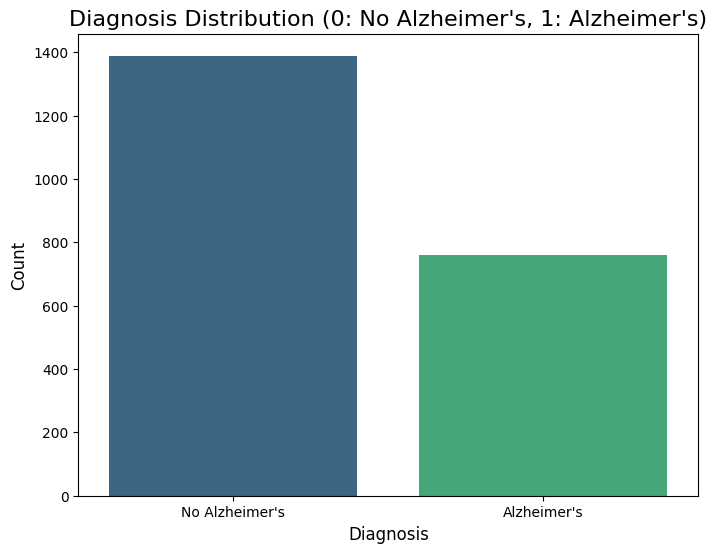

In [64]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Diagnosis', data=df, palette='viridis')
plt.title('Diagnosis Distribution (0: No Alzheimer\'s, 1: Alzheimer\'s)', fontsize=16)
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['No Alzheimer\'s', 'Alzheimer\'s'])
plt.show()

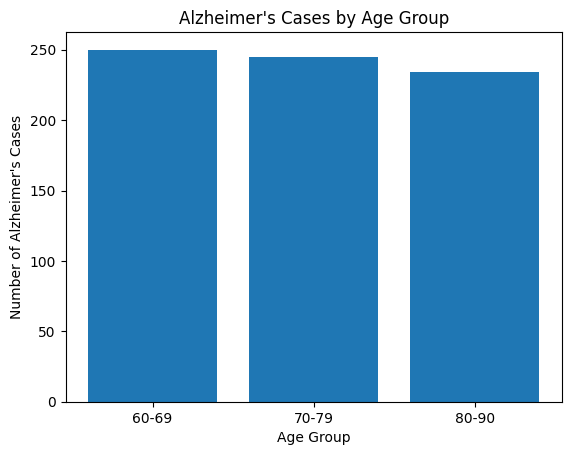

In [67]:
bins = [60, 70, 80, 90]  # Age ranges: 60-69, 70-79, 80-90
labels = ['60-69', '70-79', '80-90']

# Count Alzheimer's cases per age group
age_group_counts = df.groupby( pd.cut(df['Age'], bins=bins, labels=labels, right=False))['Diagnosis'].sum()  # Sum of 1s (Yes)

# Make a bar chart
plt.bar(labels, age_group_counts)
plt.title('Alzheimer\'s Cases by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Alzheimer\'s Cases')
plt.show()

<Axes: >

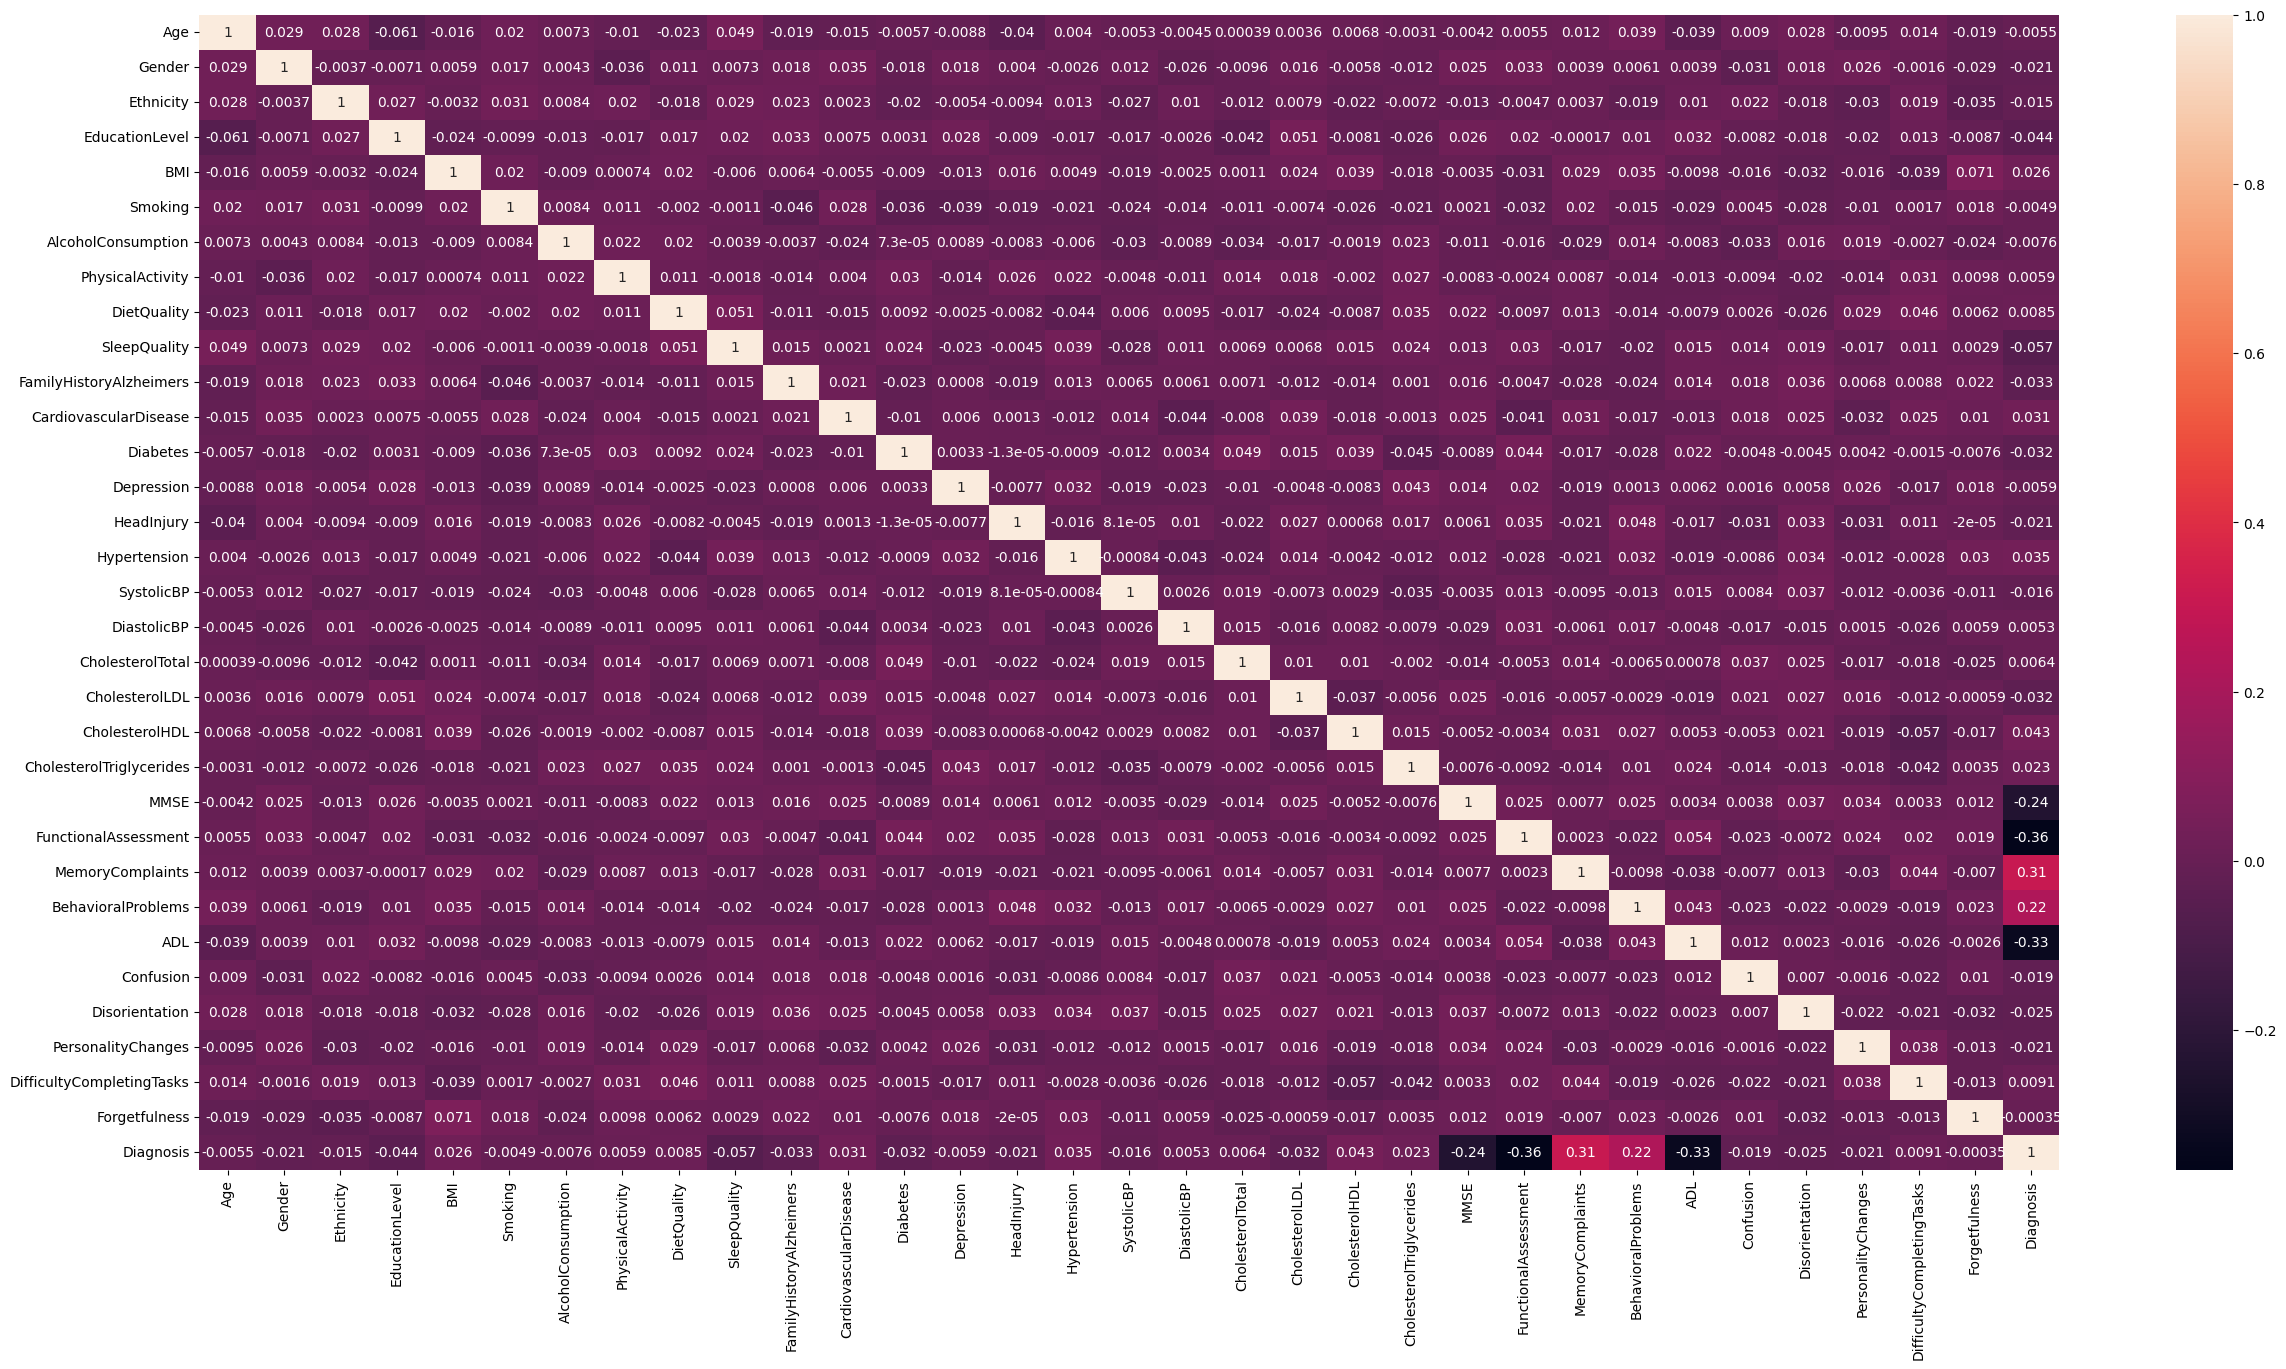

In [65]:
corr_matrix=df.corr()
plt.figure(figsize=(30,15))
sns.heatmap(corr_matrix,annot=True)

In [66]:
# Pearson correlation with target
corr = df.corr()['Diagnosis'].drop('Diagnosis')

# Pick how many features you want
N = 15   

# Top N positive correlations
top_pos = corr.sort_values(ascending=False).head(N)

# Top N negative correlations
top_neg = corr.sort_values(ascending=True).head(N)
selected = set(top_pos.index.tolist() + top_neg.index.tolist())

remaining = [col for col in corr.index if col not in selected]
print("Top Negative Correlated Features:\n", top_neg, "\n")
print("Top Positive Correlated Features:\n", top_pos)
print("Remaining Features (not selected):\n", remaining)



Top Negative Correlated Features:
 FunctionalAssessment      -0.364898
ADL                       -0.332346
MMSE                      -0.237126
SleepQuality              -0.056548
EducationLevel            -0.043966
FamilyHistoryAlzheimers   -0.032900
CholesterolLDL            -0.031976
Diabetes                  -0.031508
Disorientation            -0.024648
HeadInjury                -0.021411
Gender                    -0.020975
PersonalityChanges        -0.020627
Confusion                 -0.019186
SystolicBP                -0.015615
Ethnicity                 -0.014782
Name: Diagnosis, dtype: float64 

Top Positive Correlated Features:
 MemoryComplaints             0.306742
BehavioralProblems           0.224350
CholesterolHDL               0.042584
Hypertension                 0.035080
CardiovascularDisease        0.031490
BMI                          0.026343
CholesterolTriglycerides     0.022672
DifficultyCompletingTasks    0.009069
DietQuality                  0.008506
CholesterolTot

In [68]:
df1=df.drop(columns=['AlcoholConsumption','Depression'])

In [69]:
df1.columns

Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis'],
      dtype='object')

Random Forest Training Accuracy: 95.89%
Random Forest Testing Accuracy: 96.28%
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       209
           1       0.95      0.95      0.95       114

    accuracy                           0.96       323
   macro avg       0.96      0.96      0.96       323
weighted avg       0.96      0.96      0.96       323





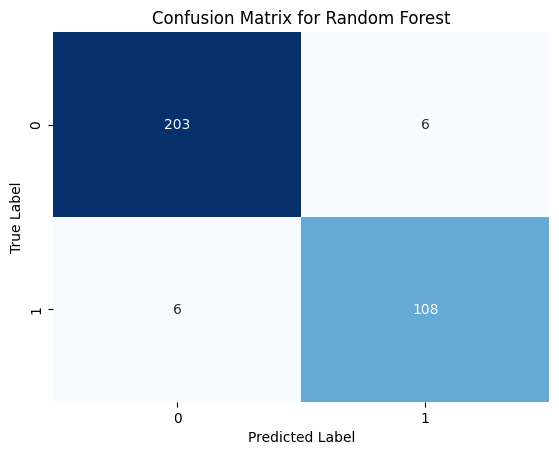

xgboost Training Accuracy: 97.21%
xgboost Testing Accuracy: 96.28%
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       209
           1       0.95      0.95      0.95       114

    accuracy                           0.96       323
   macro avg       0.96      0.96      0.96       323
weighted avg       0.96      0.96      0.96       323





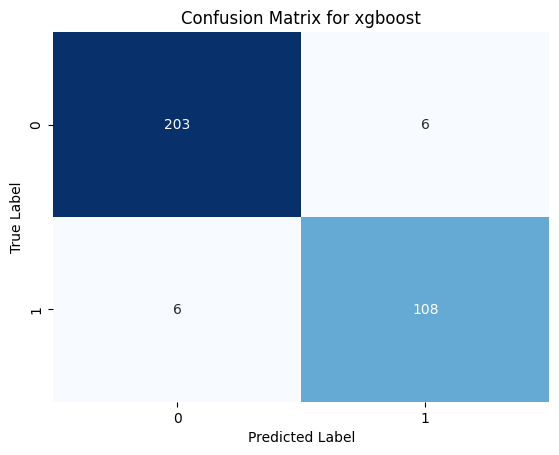

Gradient Boosting Training Accuracy: 96.17%
Gradient Boosting Testing Accuracy: 96.28%
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       209
           1       0.95      0.95      0.95       114

    accuracy                           0.96       323
   macro avg       0.96      0.96      0.96       323
weighted avg       0.96      0.96      0.96       323





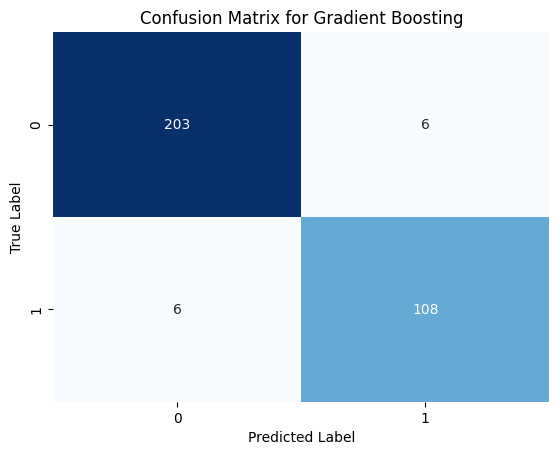

In [73]:

x=df.drop('Diagnosis',axis=1)
y=df['Diagnosis']




xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.15,random_state=42,stratify=y)
models ={
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42,bootstrap=True,max_features= None,min_samples_leaf=4,min_samples_split=2),
    'xgboost':XGBClassifier(n_estimators=200,learning_rate=0.01,max_depth=10,subsample=1.0,colsample=0.8,random_state=42),
    'Gradient Boosting':GradientBoostingClassifier(n_estimators=200, learning_rate=0.01, max_depth=5,subsample=0.6,min_samples_split=2, min_samples_leaf=2 ,random_state=42)
}
results = {}
for name, model in models.items():
    model.fit(xtrain, ytrain)
    ypred = model.predict(xtest)
    accuracy = model.score(xtest, ytest) * 100
    training_accuracy = model.score(xtrain, ytrain) * 100
    print(f"{name} Training Accuracy: {training_accuracy:.2f}%")
    results[name] = accuracy
    print(f"{name} Testing Accuracy: {accuracy:.2f}%")
    print(classification_report(ytest,ypred))
    print("\n")
     
    sns.heatmap(confusion_matrix(ytest, ypred), annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

results_df=pd.DataFrame(list(results.items()), columns=['Model', 'Testing Accuracy']).sort_values(by='Testing Accuracy', ascending=False)

In [71]:

n_estimators = 200  

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2,1.0],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

gb = GradientBoostingClassifier(
    n_estimators=n_estimators,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,              
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(xtrain, ytrain)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

best_gb = grid_search.best_estimator_
print("Train Accuracy:", best_gb.score(xtrain, ytrain) * 100)
print("Test Accuracy:", best_gb.score(xtest, ytest) * 100)


Fitting 5 folds for each of 405 candidates, totalling 2025 fits


KeyboardInterrupt: 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold


n_estimators = 200
max_depth = 10


param_grid = {
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Base RF model
rf = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    random_state=42
)

# StratifiedKFold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearch
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit
grid_search.fit(xtrain, ytrain)

# Best params + scores
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_ * 100)

# Test accuracy
best_rf = grid_search.best_estimator_
test_acc = best_rf.score(xtest, ytest) * 100
print(f"Random Forest Test Accuracy: {test_acc:.2f}%")


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'bootstrap': True, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV Accuracy: 95.01624373081818
Random Forest Test Accuracy: 96.28%


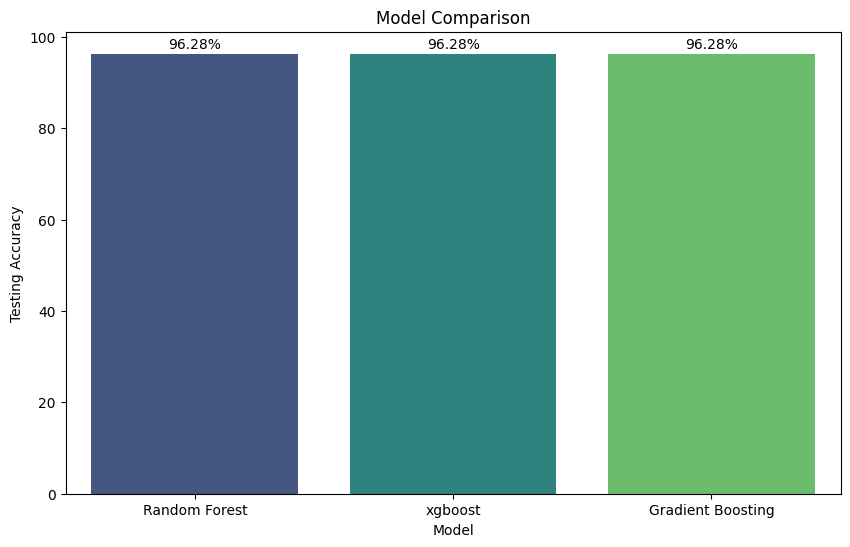

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Testing Accuracy', data=results_df, palette='viridis')
plt.title('Model Comparison')   
plt.xlabel('Model')
plt.ylabel('Testing Accuracy')
for i , v in enumerate(results_df['Testing Accuracy']):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', va='bottom')
plt.show()

Random Forest AUC-ROC: 0.9571
xgboost AUC-ROC: 0.9554
Gradient Boosting AUC-ROC: 0.9539



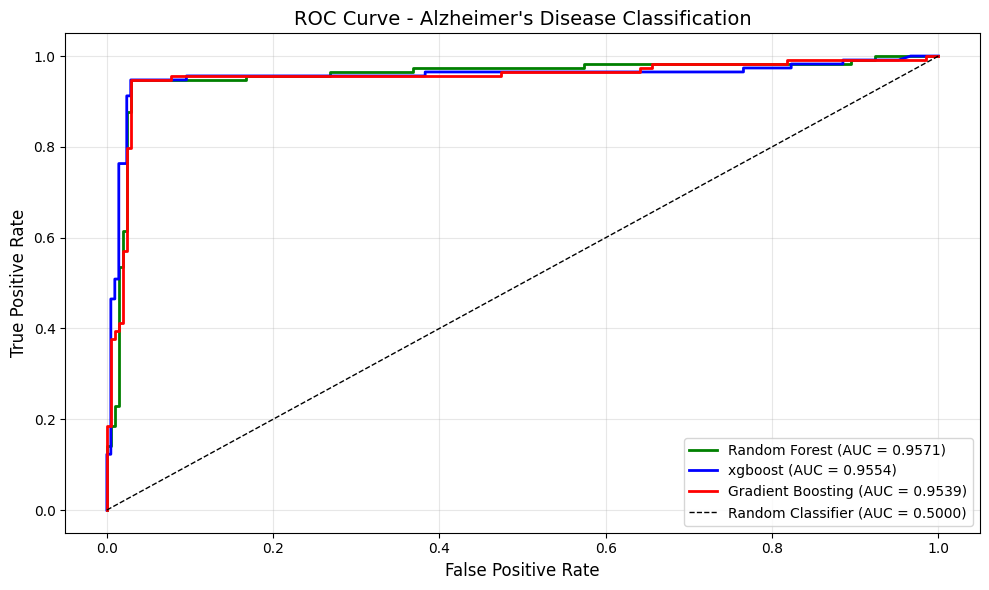

In [ ]:



# Get probability predictions for each model
prob_preds = {}
for name, model in models.items():
    prob_preds[name] = model.predict_proba(xtest)[:, 1]

# Calculate AUC scores
auc_rf = roc_auc_score(ytest, prob_preds['Random Forest'])
auc_xgb = roc_auc_score(ytest, prob_preds['xgboost'])
auc_gb = roc_auc_score(ytest, prob_preds['Gradient Boosting'])

print(f"Random Forest AUC-ROC: {auc_rf:.4f}")
print(f"xgboost AUC-ROC: {auc_xgb:.4f}")
print(f"Gradient Boosting AUC-ROC: {auc_gb:.4f}\n")

# Calculate ROC curves
fpr_rf, tpr_rf, _ = roc_curve(ytest, prob_preds['Random Forest'])
fpr_xgb, tpr_xgb, _ = roc_curve(ytest, prob_preds['xgboost'])
fpr_gb, tpr_gb, _ = roc_curve(ytest, prob_preds['Gradient Boosting'])

# Plot ROC curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', linewidth=2, color='green')
plt.plot(fpr_xgb, tpr_xgb, label=f'xgboost (AUC = {auc_xgb:.4f})', linewidth=2, color='blue')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.4f})', linewidth=2, color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Alzheimer\'s Disease Classification', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

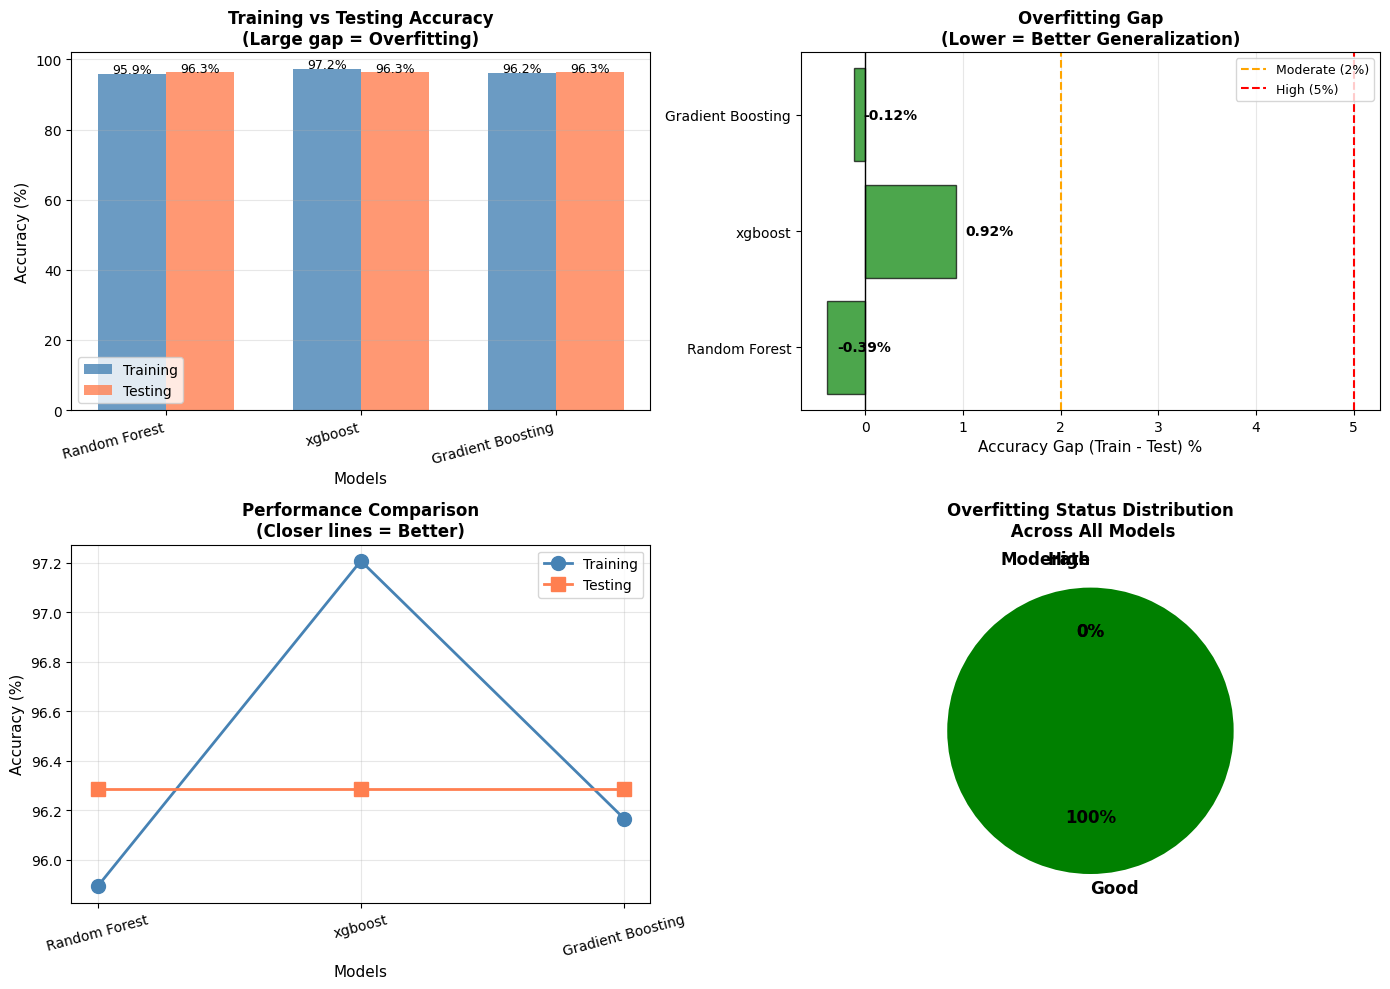

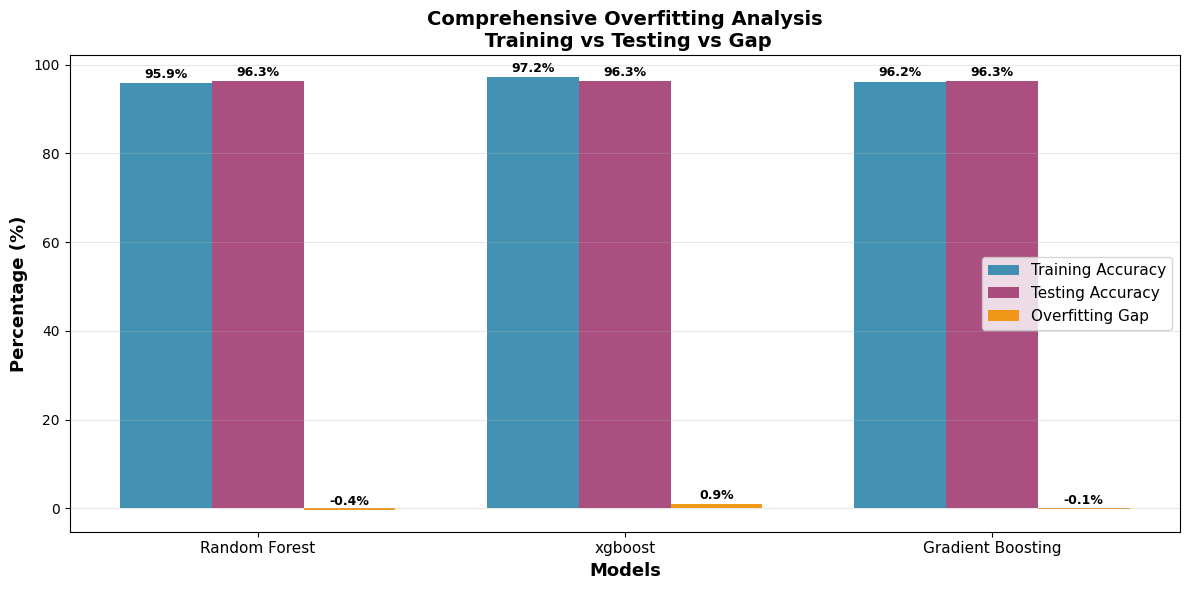


SUMMARY TABLE
Model                Train Acc    Test Acc     Gap        Status         
----------------------------------------------------------------------
Random Forest             95.89%      96.28%    -0.39% ✓ Good         
xgboost                   97.21%      96.28%     0.92% ✓ Good         
Gradient Boosting         96.17%      96.28%    -0.12% ✓ Good         


In [82]:


# After your training loop, collect the accuracy data
train_scores = []
test_scores = []
model_names = []

for name, model in models.items():
    train_acc = model.score(xtrain, ytrain) * 100
    test_acc = model.score(xtest, ytest) * 100
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    model_names.append(name)

# Calculate overfitting gaps
gaps = [train_scores[i] - test_scores[i] for i in range(len(model_names))]



# Visualization 1: Training vs Testing Accuracy Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Bar Chart - Training vs Testing
x_pos = np.arange(len(model_names))
width = 0.35

axes[0, 0].bar(x_pos - width/2, train_scores, width, label='Training', color='steelblue', alpha=0.8)
axes[0, 0].bar(x_pos + width/2, test_scores, width, label='Testing', color='coral', alpha=0.8)
axes[0, 0].set_xlabel('Models', fontsize=11)
axes[0, 0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0, 0].set_title('Training vs Testing Accuracy\n(Large gap = Overfitting)', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (train, test) in enumerate(zip(train_scores, test_scores)):
    axes[0, 0].text(i - width/2, train + 0.2, f'{train:.1f}%', ha='center', fontsize=9)
    axes[0, 0].text(i + width/2, test + 0.2, f'{test:.1f}%', ha='center', fontsize=9)

# Plot 2: Overfitting Gap (Horizontal Bar)
colors = ['green' if g < 2 else 'orange' if g < 5 else 'red' for g in gaps]

axes[0, 1].barh(model_names, gaps, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Accuracy Gap (Train - Test) %', fontsize=11)
axes[0, 1].set_title('Overfitting Gap\n(Lower = Better Generalization)', fontsize=12, fontweight='bold')
axes[0, 1].axvline(x=2, color='orange', linestyle='--', linewidth=1.5, label='Moderate (2%)')
axes[0, 1].axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='High (5%)')
axes[0, 1].axvline(x=0, color='black', linewidth=1)
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(axis='x', alpha=0.3)

# Add value labels
for i, gap in enumerate(gaps):
    axes[0, 1].text(gap + 0.1, i, f'{gap:.2f}%', va='center', fontsize=10, fontweight='bold')

# Plot 3: Accuracy Comparison Line Plot
axes[1, 0].plot(model_names, train_scores, marker='o', linewidth=2, markersize=10, 
                label='Training', color='steelblue')
axes[1, 0].plot(model_names, test_scores, marker='s', linewidth=2, markersize=10, 
                label='Testing', color='coral')
axes[1, 0].set_ylabel('Accuracy (%)', fontsize=11)
axes[1, 0].set_xlabel('Models', fontsize=11)
axes[1, 0].set_title('Performance Comparison\n(Closer lines = Better)', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=15)

# Plot 4: Overfitting Status Summary
status_counts = {'Good': 0, 'Moderate': 0, 'High': 0}
for gap in gaps:
    if gap < 2:
        status_counts['Good'] += 1
    elif gap < 5:
        status_counts['Moderate'] += 1
    else:
        status_counts['High'] += 1

colors_pie = ['green', 'orange', 'red']
explode = (0.05, 0.05, 0.05)
axes[1, 1].pie(status_counts.values(), labels=status_counts.keys(), autopct='%1.0f%%',
               colors=colors_pie, explode=explode, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1, 1].set_title('Overfitting Status Distribution\n Across All Models', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Additional Visualization: Detailed Model Comparison
fig, ax = plt.subplots(figsize=(12, 6))

# Create grouped data
x = np.arange(len(model_names))
width = 0.25

bars1 = ax.bar(x - width, train_scores, width, label='Training Accuracy', color='#2E86AB', alpha=0.9)
bars2 = ax.bar(x, test_scores, width, label='Testing Accuracy', color='#A23B72', alpha=0.9)
bars3 = ax.bar(x + width, gaps, width, label='Overfitting Gap', color='#F18F01', alpha=0.9)

ax.set_xlabel('Models', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=13, fontweight='bold')
ax.set_title('Comprehensive Overfitting Analysis\n Training vs Testing vs Gap', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary Table
print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(f"{'Model':<20} {'Train Acc':<12} {'Test Acc':<12} {'Gap':<10} {'Status':<15}")
print("-" * 70)
for i, name in enumerate(model_names):
    gap = gaps[i]
    if gap < 2:
        status = "✓ Good"
    elif gap < 5:
        status = "⚠ Moderate"
    else:
        status = "⚠ High"
    print(f"{name:<20} {train_scores[i]:>10.2f}% {test_scores[i]:>10.2f}% {gap:>8.2f}% {status:<15}")
print("=" * 70)